# FIT5196 Assessment 1 — EDA Notebook

**Group:** Group001
**Members:** Echo Zhao · Jasmine · Yandu Wang · Shawn

This notebook reads the six standardised CSVs produced by `Group001_solution.ipynb` and
nothing else. It does not re-run any cleaning: every value here is a value that was exported,
validated and shipped. It is the reproducibility evidence for `Group001_EDA.pdf`.

## 0. Configuration and data loading

Load the six standardised CSVs produced by the solution notebook. Keep paths
relative/configurable and use explicit read options where the literal string
`NaN` must remain visible.


Two cells. The first mounts Google Drive and does nothing anywhere else, so the configuration
cell below stays free of environment-specific code. The second finds the six CSVs from a short
list of candidate folders — the first entry is the layout produced by unzipping the submission.

**This notebook needs only the six CSVs.** It never re-runs the cleaning pipeline, so nobody has
to run the solution notebook to work here.

In [3]:
# Colab only. Does nothing elsewhere.
try:
    from google.colab import drive
    from pathlib import Path as _Path
    import os as _os

    drive.mount('/content/drive')
    _root = _Path('/content/drive/MyDrive')
    _found = sorted({p.parent for p in _root.rglob('Group001_orders_standardised.csv')})
    if len(_found) == 1:
        _os.chdir(_found[0])
        print('cwd:', _found[0])
    elif len(_found) > 1:
        # Never guess. Several copies of the six CSVs means someone re-ran the pipeline into
        # their own folder, and picking the first would silently analyse the wrong set.
        print('Several folders on this drive hold the six CSVs:')
        for _p in _found:
            print('   ', _p)
        raise SystemExit('Pick one: set OUTPUT_DIR by hand in the next cell, or leave only '
                         'the shared copy on the drive.')
    else:
        print('Six CSVs not found under MyDrive. Put them in a folder there, or upload them.')
except ImportError:
    pass   # not on Colab

In [4]:
# --- Section 0: configuration ---
from pathlib import Path

GROUP_ID = 'Group001'
CSV_NAME = f'{GROUP_ID}_orders_standardised.csv'

# The six CSVs, wherever they are. The first candidate is the layout produced by
# unzipping the submission; the rest cover the shared-drive folders.
OUTPUT_CANDIDATES = [Path('outputs'), Path('.'), Path('../outputs'),
                     Path('02_Outputs'), Path('../02_Outputs'),
                     Path('../00_Master/outputs')]
OUTPUT_DIR = next((p for p in OUTPUT_CANDIDATES if (p / CSV_NAME).exists()), None)
if OUTPUT_DIR is None:                       # last resort: search downwards from here
    hit = next(Path('.').rglob(CSV_NAME), None)
    OUTPUT_DIR = hit.parent if hit else None
assert OUTPUT_DIR is not None, (
    f'{CSV_NAME} not found. Put the six CSVs in an "outputs" folder beside this notebook. '
    f'Tried: {[str(p) for p in OUTPUT_CANDIDATES]}')
print('reading from', OUTPUT_DIR.resolve().name)

# Which copy of the six CSVs is this? Four people can each produce a set; a short fingerprint
# makes it visible at a glance that every figure in this notebook was built on the same one.
import hashlib
print()
for _p in sorted(OUTPUT_DIR.glob(f'{GROUP_ID}_*_standardised.csv')):
    _h = hashlib.sha256(_p.read_bytes()).hexdigest()[:12]
    print(f'   {_h}  {_p.name}')

reading from outputs

   3a299a08a28d  Group001_customers_standardised.csv
   600bbaabb82b  Group001_deliveries_standardised.csv
   f5ec47654da2  Group001_order_items_standardised.csv
   2fe0708076c8  Group001_orders_standardised.csv
   8129408eba59  Group001_product_reviews_standardised.csv
   c81738a79436  Group001_products_standardised.csv


In [5]:
# --- Section 0: load the six tables ---
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 200)
plt.rcParams.update({'figure.dpi': 110, 'figure.figsize': (7.5, 4.2),
                     'axes.grid': True, 'grid.alpha': 0.25, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 10})

TABLES = ['orders', 'order_items', 'customers', 'deliveries', 'products', 'product_reviews']

# keep_default_na=False so the literal three-character 'NaN' sentinel stays visible as text
# rather than becoming a missing value, which would silently change every denominator.
T = {t: pd.read_csv(OUTPUT_DIR / f'{GROUP_ID}_{t}_standardised.csv', keep_default_na=False)
     for t in TABLES}

orders          = T['orders']
order_items     = T['order_items']
customers       = T['customers']
deliveries      = T['deliveries']
products        = T['products']
product_reviews = T['product_reviews']

for t in TABLES:
    print(f'{t:16s} {len(T[t]):>7,} rows x {T[t].shape[1]:>2} cols')

orders             5,000 rows x 23 cols
order_items       15,685 rows x  6 cols
customers            500 rows x 20 cols
deliveries         5,000 rows x 20 cols
products           1,000 rows x 21 cols
product_reviews    7,000 rows x 21 cols


### 0.1 The grain of each table, and the join guard

Every metric in this notebook is calculated at its intended grain. The tables are one-to-many
in three places, so a join made in the wrong order multiplies rows and inflates any sum taken
afterwards:

| Table | One row per | Rows |
|---|---|---|
| `orders` | order | 5,000 |
| `order_items` | item within an order (1–5 per order) | 15,685 |
| `customers` | customer | 500 |
| `deliveries` | order | 5,000 |
| `products` | product | 1,000 |
| `product_reviews` | reviewed order item | 7,000 |

`at_grain()` below is used on every join in this notebook. It states the row count expected
after the join and fails if the join changed it, so an inflated revenue figure cannot survive
to a chart.

In [6]:
# --- Section 0.1: the guard every join in this notebook passes through ---

def at_grain(df, expected_rows, label):
    """Assert a join did not multiply rows, and say so in the output.

    A one-to-many join is not wrong in itself; summing a parent column after one is.
    Naming the expected row count at the join is what makes the difference visible.
    """
    assert len(df) == expected_rows, (
        f'{label}: {len(df):,} rows after the join, expected {expected_rows:,} — '
        f'the join multiplied rows, so any sum taken now is inflated')
    print(f'{label}: {len(df):,} rows, grain preserved')
    return df


# Numeric columns arrive as text because of keep_default_na=False. Cast where needed.
def num(series):
    return pd.to_numeric(series, errors='coerce')


for t in TABLES:
    key = T[t].columns[0]
    print(f'{t:16s} one row per {key:<16s} {T[t][key].is_unique}')

orders           one row per order_id         True
order_items      one row per order_item_id    True
customers        one row per customer_id      True
deliveries       one row per delivery_id      True
products         one row per product_id       True
product_reviews  one row per review_id        True


## 1. Context and data-preparation assurance

Briefly define the business context and data scope. Summarise 3-5 material
transformation decisions and 4-6 material validation results by citing stable
`MAP-...` and `VAL-...` IDs. Do not repeat the complete mapping or notebook.


*Owner: Yandu. Three to five transformation decisions and four to six validation results,
citing `MAP-` and `VAL-` IDs from the mapping CSV and the validation register. Do not repeat
either artefact — this is the short assurance narrative the report's section 2 is built from.*

Candidates, each already evidenced in the solution notebook:

- **The canonical-row rule** — normalise, then keep one row per business key (`VAL-FLOW-07`,
  `VAL-FLOW-09`, `VAL-FLOW-10`). 0 field disagreements, within source or across sources.
- **The monetary chain** — the five money fields are rebuilt rather than copied, and the
  discount is percentage points applied before delivery with GST divided out, not added
  (`VAL-ARITH-01` to `VAL-ARITH-04`; the control shows the wrong formula matches 0 of 5,000).
- **`delivery_note_clean` is a direct copy** — a structured category, not narrative
  (`VAL-TEXT-01b`, `MAP-deliveries-20`).
- **Extraction runs on the raw text, measurement on the cleaned text** (`VAL-TEXT-06`,
  `VAL-TEXT-14`, `VAL-TEXT-15`).
- **The sentinel is three characters** — `coupon_code` and `promo_code` carry it on the same
  3,127 orders and nothing else does (`VAL-TEXT-11`).

## 2. Assessed EDA visualisations

Submit 6-8 clearly labelled assessed figures. Across the set, cover all six
published categories, at least four tables and at least two valid relational
analyses. For each figure state the question, observation unit, denominator,
tables/join keys, interpretation and material limitation.


### Figure 1: Univariate distribution or composition

**Owner:** Yandu

**Question:** How is order value distributed across the canonical orders, and is it skewed enough that a mean would mislead?

**Observation unit and denominator:** One order. Denominator: all 5,000 canonical orders.

**Tables and join keys:** `orders` only — no join.

**How to build it:** A 60-bin histogram of order_total with the median and mean drawn as vertical lines and labelled, so the skew is visible rather than asserted. A histogram rather than an ECDF because the question is about shape — where the mass sits and how far the tail runs — which a histogram shows directly.

**Interpretation and limitation:** Order value is strongly right-skewed. The median order is AUD 2,502 but the mean is AUD 2,983 — 19% higher — and the mean sits above 59% of all 5,000 orders. Values run from AUD 22 to AUD 17,720, and the top 5% exceed AUD 7,135, nearly three times the median. For anything describing a typical order, plan with the median; the mean is the right summary only when the question is about totals, since mean x order count is revenue.

order_total is not basket size: it is net of the coupon discount and includes delivery_charges, so it mixes what the customer paid with a shipping component that does not scale with the goods. A question about typical basket size would want order_price instead, and the skew there may differ.

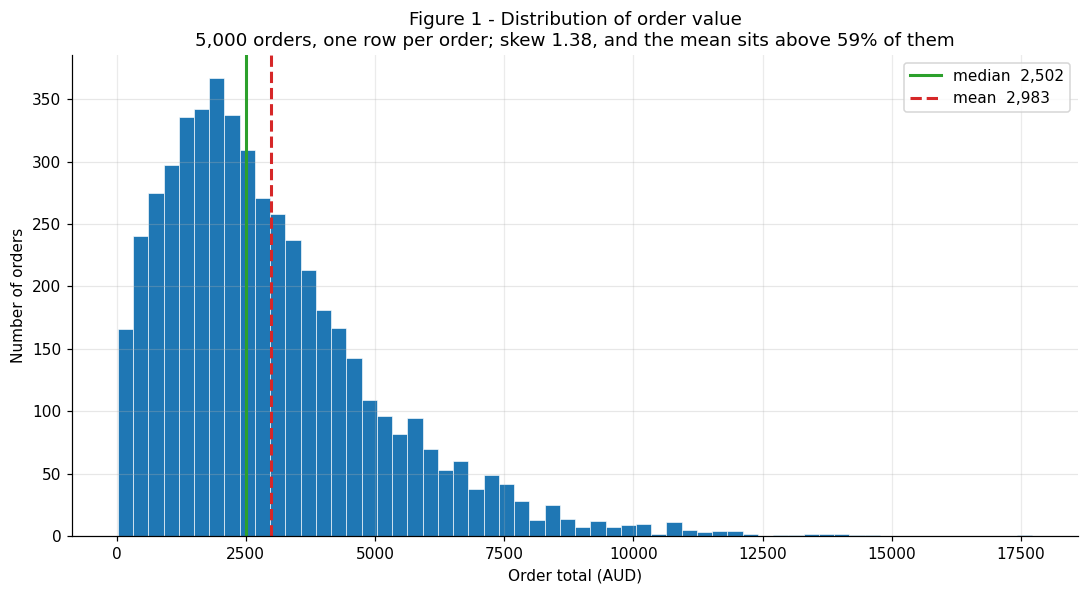

count     5000.00
mean      2983.18
std       2130.89
min         22.25
5%         431.30
25%       1441.17
50%       2501.96
75%       4024.73
95%       7134.79
max      17720.48


In [28]:
# --- Figure 1 (Yandu) ---
t = num(orders['order_total'])
mean, median = t.mean(), t.median()
below = (t < mean).mean() * 100

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.hist(t, bins=60, color='tab:blue', edgecolor='white', linewidth=.4)
ax.axvline(median, color='tab:green', lw=2, label=f'median  {median:,.0f}')
ax.axvline(mean, color='tab:red', lw=2, ls='--', label=f'mean  {mean:,.0f}')

ax.set_xlabel('Order total (AUD)')
ax.set_ylabel('Number of orders')
ax.set_title('Figure 1 - Distribution of order value\n'
             f'{len(t):,} orders, one row per order; skew {t.skew():.2f}, '
             f'and the mean sits above {below:.0f}% of them')
ax.legend()
ax.grid(axis='y', alpha=.3)
plt.tight_layout()
plt.show()

print(t.describe(percentiles=[.05, .25, .5, .75, .95]).round(2).to_string())

### Figure 2: Bivariate relationship or group comparison

**Owner:** Echo

**Question:** Which product categories earn the most revenue, and does the ranking change when the same categories are ranked by units sold?

**Observation unit and denominator:** One order line. All 15,685 canonical order lines. Units sold is `sum(quantity)` over those lines — 20,154 purchased units, not a distinct count of products.

**Tables and join keys:** `order_items` joined to `products` on `product_id`, many lines to one product. Revenue is summed at line grain.

**Result and limitation:** The two rankings are near-opposite. Laptop leads on gross line revenue ($2.75m) but is 9th of ten on units (1,397), while Accessory is 1st on units (3,051) and 10th on revenue ($0.56m): category price level, not volume, drives revenue. Both panels are drawn in one shared category order so the rank change is visible rather than asserted. The cell also prints the grain check — summing `order_total` after this line-level join returns $52.7m against the true $14.9m, a 3.53x inflation, because an order repeats once for every item it carries. Limitation: `line_revenue` is gross, so $3.12m of order-level coupon discount separates the $16.47m line total from the $14.92m invoiced, and it cannot be attributed to any one category.


order_items + products: 15,685 rows, grain preserved
items + orders: 15,685 rows, grain preserved
Correct order total: $14,915,886.94
After item join:     $52,722,538.16 (3.53x; orders repeat per item)


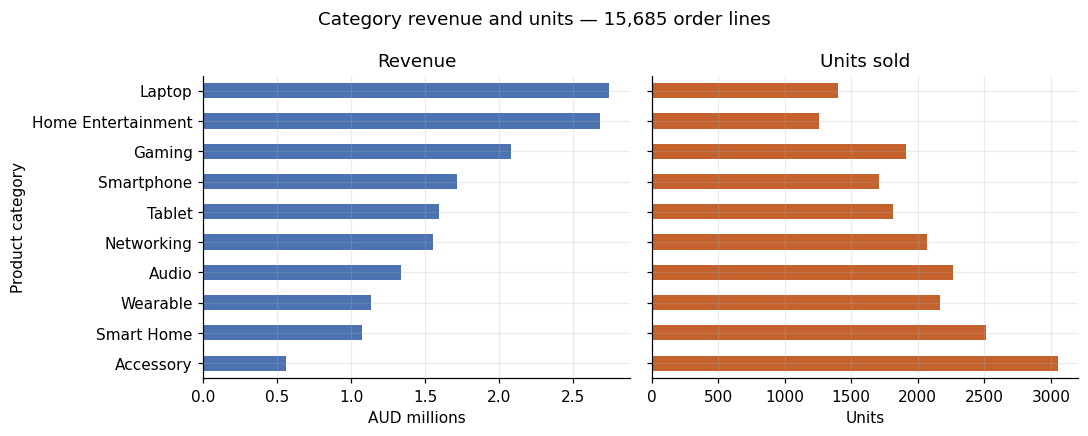

In [ ]:
# --- Figure 2 (Echo) ---

# Step 1: Add each product's category to the order-item table.
# many_to_one means many order lines may use one product, but each product ID
# must have only one matching row in the products table.
lines = order_items.merge(products[['product_id', 'category']], on='product_id', validate='many_to_one')
# Check that the join did not add or remove any of the 15,685 order lines.
at_grain(lines, len(order_items), 'order_items + products')
lines[['quantity', 'line_revenue']] = lines[['quantity', 'line_revenue']].apply(num)

# Step 2: Show why order totals must not be summed after an item-level join.
# An order with several items appears several times after this join.
repeated = lines.merge(orders[['order_id', 'order_total']], on='order_id')
at_grain(repeated, len(lines), 'items + orders')
correct = num(orders['order_total']).sum()
wrong = num(repeated['order_total']).sum()
print(f'Correct order total: ${correct:,.2f}')
print(f'After item join:     ${wrong:,.2f} ({wrong / correct:.2f}x; orders repeat per item)')

# Step 3: Calculate the two category totals used in the figure.
# Revenue numerator = sum of line_revenue within each category.
# Units numerator = sum of quantity within each category. This includes repeat
# purchases and quantity > 1; it is not a distinct count.
cat = lines.groupby('category').agg(
    revenue=('line_revenue', 'sum'), units_sold=('quantity', 'sum'))
# Step 4: Rank each measure separately (1 means the largest category).
cat['revenue_rank'] = cat['revenue'].rank(method='min', ascending=False).astype(int)
cat['units_rank'] = cat['units_sold'].rank(method='min', ascending=False).astype(int)
print(f"Gross line revenue denominator: ${cat['revenue'].sum():,.2f}")
print(f"Units sold: {cat['units_sold'].sum():,} across "
      f"{lines['order_item_id'].nunique():,} distinct order lines "
      '(repeat purchases included)')
print(cat.sort_values('revenue', ascending=False)
      [['revenue', 'revenue_rank', 'units_sold', 'units_rank']].to_string())
# Step 5: Draw both measures in the same revenue-sorted category order.
# Keeping one order makes differences between the two rankings easy to see.
cat = cat.sort_values('revenue')
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
cat.revenue.div(1e6).plot.barh(ax=axes[0], title='Gross line revenue', color='#4C72B0')
cat.units_sold.plot.barh(ax=axes[1], title='Purchased units (same category order)', color='#C4622D')
axes[0].set(xlabel='AUD millions', ylabel='Product category')
axes[1].set(xlabel='Units sold = sum(quantity)', ylabel='')
fig.suptitle(f'Category revenue rank versus unit-sales rank — {len(lines):,} order lines')
fig.tight_layout()
plt.show()

### Figure 3: Temporal pattern

**Owner:** Jasmine

**Question:** Does monthly revenue move because there are more orders, or because orders get bigger?

**Observation unit and denominator:** One order. Denominator: all 5,000 canonical orders, grouped by month.

**Tables and join keys:** `orders` only — no join.

**How to build it:** `order_timestamp` is 2018 throughout; `delivered_date` runs into January 2019 for orders placed late in December, so a temporal range constraint belongs on the order timestamp and would report 76 false failures on the delivery date.

**Interpretation and limitation:** Monthly revenue varies by only 6.1% across 2018 (coefficient of variation), and neither component drives it — order count varies 4.2% and mean order value 4.0%, so the two contribute roughly equally rather than one masking the other. Volume stays between 384 and 443 orders a month, and revenue between AUD 1.10m and 1.35m.

At roughly 417 orders a month, a 4% swing is close to what sampling variation alone would produce, so no individual month is distinguishable from the rest on this evidence. A single calendar year also gives no second cycle, so the shape can be described but not called seasonal.

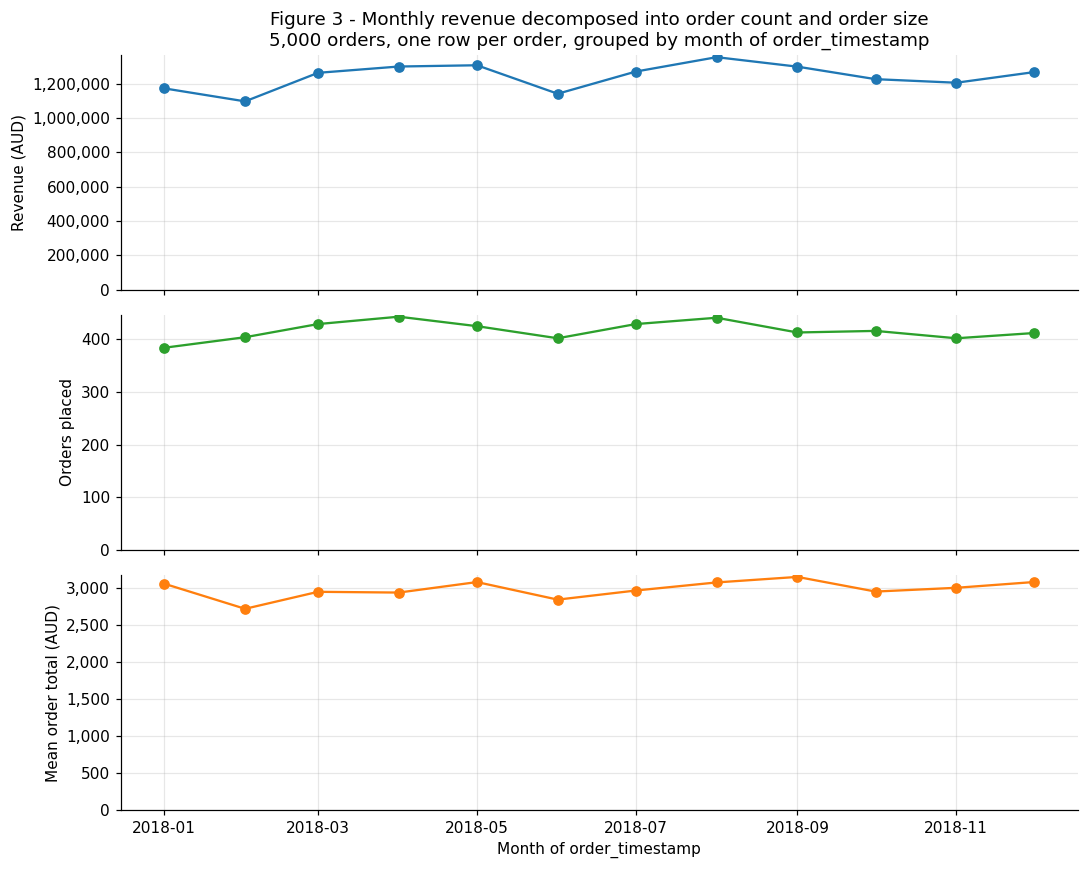

variation across the 12 months (coefficient of variation, %)
revenue       6.1
orders        4.2
mean_value    4.0 

first order 2018-01-01   last order 2018-12-31
orders per month  min 384  max 443


In [16]:
# --- Figure 3 (Jasmine) ---

from matplotlib.ticker import FuncFormatter

df = orders.copy()
df['ts']    = pd.to_datetime(df['order_timestamp'])
df['total'] = num(df['order_total'])
df['month'] = df['ts'].dt.to_period('M')

m = df.groupby('month').agg(revenue=('total', 'sum'),
                            orders=('order_id', 'size'),
                            mean_value=('total', 'mean'))
m.index = m.index.to_timestamp()

fig, ax = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
panels = [('revenue',    'Revenue (AUD)',          'tab:blue'),
          ('orders',     'Orders placed',          'tab:green'),
          ('mean_value', 'Mean order total (AUD)', 'tab:orange')]

for a, (col, label, colour) in zip(ax, panels):
    a.plot(m.index, m[col], marker='o', color=colour)
    a.set_ylabel(label)
    a.set_ylim(bottom=0)
    a.grid(alpha=.3)
    a.yaxis.set_major_formatter(FuncFormatter(lambda v, p: f'{v:,.0f}'))

ax[0].set_title('Figure 3 - Monthly revenue decomposed into order count and order size\n'
                f'{len(df):,} orders, one row per order, grouped by month of order_timestamp')
ax[-1].set_xlabel('Month of order_timestamp')

plt.tight_layout()
plt.show()

# Numbers for the interpretation sentence.
cols = ['revenue', 'orders', 'mean_value']
cv = m[cols].std() / m[cols].mean() * 100
print('variation across the 12 months (coefficient of variation, %)')
print(cv.round(1).to_string(), '\n')
print(f"first order {df['ts'].min():%Y-%m-%d}   last order {df['ts'].max():%Y-%m-%d}")
print(f"orders per month  min {m['orders'].min():,}  max {m['orders'].max():,}")

### Figure 4: Multivariate or segmented relationship (also: operational)

**Owner:** Jasmine

**Question:** Does the on-time rate differ by carrier, service level or dispatching warehouse, and do they interact?

**Observation unit and denominator:** One delivery. Denominator: all 5,000 deliveries.

**Tables and join keys:**  deliveries joined to orders on order_id, one-to-one, verified by at_grain — the join supplies nearest_warehouse.

**How to build it:** Use on_time_in_full, not delivery_note_clean: the note is the same partition as the outcome columns and adds nothing. Dot-and-interval with a Wilson 95% interval per cell, and n printed beside each row.

**Interpretation and limitation:** Dot-and-interval rather than bars: the finding is that these rates are not distinguishable, and bars invite the reader to rank them. The 95% Wilson interval on each cell carries the uncertainty, so a 36-delivery cell is visibly wider than a 470-delivery one.

On-time performance is 89.4% across all 5,000 deliveries and barely moves. All 24 carrier x service x warehouse cells fall between 81.8% and 95.8%, and pooled across warehouses Express reaches 89.7% against Standard's 89.4% — 0.3 percentage points on 901 Express deliveries, well within one standard error. Express also buys no shorter promise: mean promised_days is 5.03 against 4.99.

The apparent interaction is not evidence of one. The Express-minus-Standard gap swings from -10.0 to +7.0 points, but every large swing sits in an Express cell of 36 to 100 deliveries. Express is 18% of deliveries, so this design cannot resolve an interaction that would matter operationally.

deliveries + orders: 5,000 rows, grain preserved


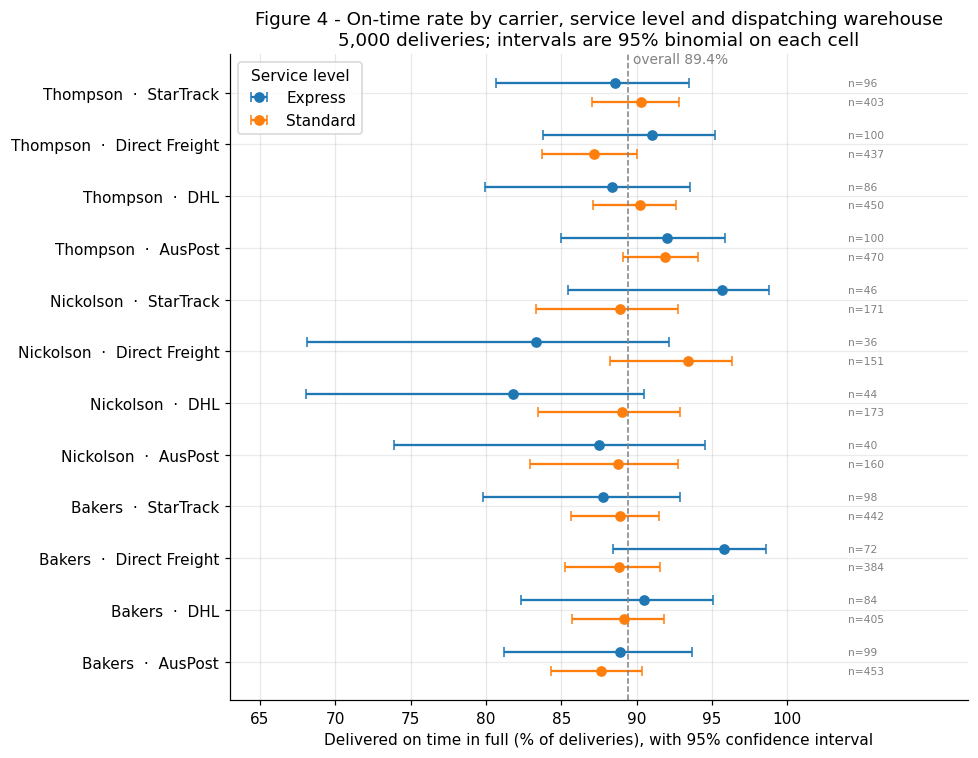

service_level                     Express  Standard  Express - Standard
nearest_warehouse carrier                                              
Bakers            AusPost            88.9      87.6                 1.3
                  DHL                90.5      89.1                 1.3
                  Direct Freight     95.8      88.8                 7.0
                  StarTrack          87.8      88.9                -1.2
Nickolson         AusPost            87.5      88.8                -1.2
                  DHL                81.8      89.0                -7.2
                  Direct Freight     83.3      93.4               -10.0
                  StarTrack          95.7      88.9                 6.8
Thompson          AusPost            92.0      91.9                 0.1
                  DHL                88.4      90.2                -1.9
                  Direct Freight     91.0      87.2                 3.8
                  StarTrack          88.5      90.3             

In [24]:
# --- Figure 4 (Jasmine) ---
joined = deliveries.merge(orders[['order_id', 'nearest_warehouse']], on='order_id')
at_grain(joined, len(deliveries), 'deliveries + orders')
joined['on_time'] = joined['on_time_in_full'].astype(str).str.lower() == 'true'

g = (joined.groupby(['nearest_warehouse', 'carrier', 'service_level'])['on_time']
           .agg(rate='mean', n='size').reset_index())
g['pct'] = g['rate'] * 100

# Wilson interval - stays inside 0-100 where the normal approximation does not.
z, p, n = 1.96, g['rate'], g['n']
centre = (p + z**2 / (2*n)) / (1 + z**2 / n)
half   = z * (p*(1-p)/n + z**2/(4*n**2)) ** .5 / (1 + z**2 / n)
g['lo'], g['hi'] = (centre - half) * 100, (centre + half) * 100

g['y']   = g.groupby(['nearest_warehouse', 'carrier']).ngroup()
g['y']  += g['service_level'].map({'Express': .18, 'Standard': -.18})

overall = joined['on_time'].mean() * 100
fig, ax = plt.subplots(figsize=(9, 7))

for lv, colour in [('Express', 'tab:blue'), ('Standard', 'tab:orange')]:
    s = g[g['service_level'] == lv]
    ax.errorbar(s['pct'], s['y'], xerr=[s['pct'] - s['lo'], s['hi'] - s['pct']],
                fmt='o', color=colour, capsize=3, label=lv)

for _, r in g.iterrows():
    ax.text(104, r['y'], f"n={int(r['n']):,}", va='center', fontsize=7, color='grey')

ax.axvline(overall, color='grey', ls='--', lw=1)
ax.text(overall + .3, g['y'].max() + .4, f'overall {overall:.1f}%', color='grey', fontsize=9)

labels = g.sort_values('y').drop_duplicates(['nearest_warehouse', 'carrier'])
ax.set_yticks(labels['y'].round())
ax.set_yticklabels(labels['nearest_warehouse'] + '  ·  ' + labels['carrier'])
ax.set_xlim(63, 112)
ax.set_xticks(range(65, 101, 5))
ax.set_xlabel('Delivered on time in full (% of deliveries), with 95% confidence interval')
ax.grid(axis='x', alpha=.3)
ax.legend(title='Service level', loc='upper left')
ax.set_title('Figure 4 - On-time rate by carrier, service level and dispatching warehouse\n'
             f'{len(joined):,} deliveries; intervals are 95% binomial on each cell')
plt.tight_layout()
plt.show()

# Numbers for the interpretation sentence.
gap = g.pivot_table(index=['nearest_warehouse', 'carrier'], columns='service_level', values='pct')
gap['Express - Standard'] = gap['Express'] - gap['Standard']
print(gap.round(1).to_string())
print(f"\noverall {overall:.1f}% of {len(joined):,}")
print(joined.groupby('service_level')['on_time'].agg(['mean', 'size']).round(3).to_string())

### Figure 5: Review or text behaviour

**Owner:** Shawn

**Question:** Do rating, review length and script relate to one another — do longer reviews rate lower, and do non-Latin reviews differ?

**Observation unit and denominator:** One review. Denominator: all 7,000 canonical reviews.

**Tables and join keys:** `product_reviews` only — no join.

**Method:** Compare the distribution of `review_length_chars` across ratings and script groups. Group sizes are printed on the x-axis, and a log length scale is used because review lengths span 180–2,492 characters.

**Interpretation and limitation:** Across 7,000 reviews, the 271 containing non-Latin script had a median cleaned length of 607 characters versus 927 for 6,729 Latin-only reviews, and neither group showed a clear monotonic rating–length pattern. The non-Latin group is small and language-specific writing conventions may explain the difference, so this descriptive result should not be interpreted causally.


      script_group    n  median_chars
Contains non-Latin  271         607.0
        Latin only 6729         927.0


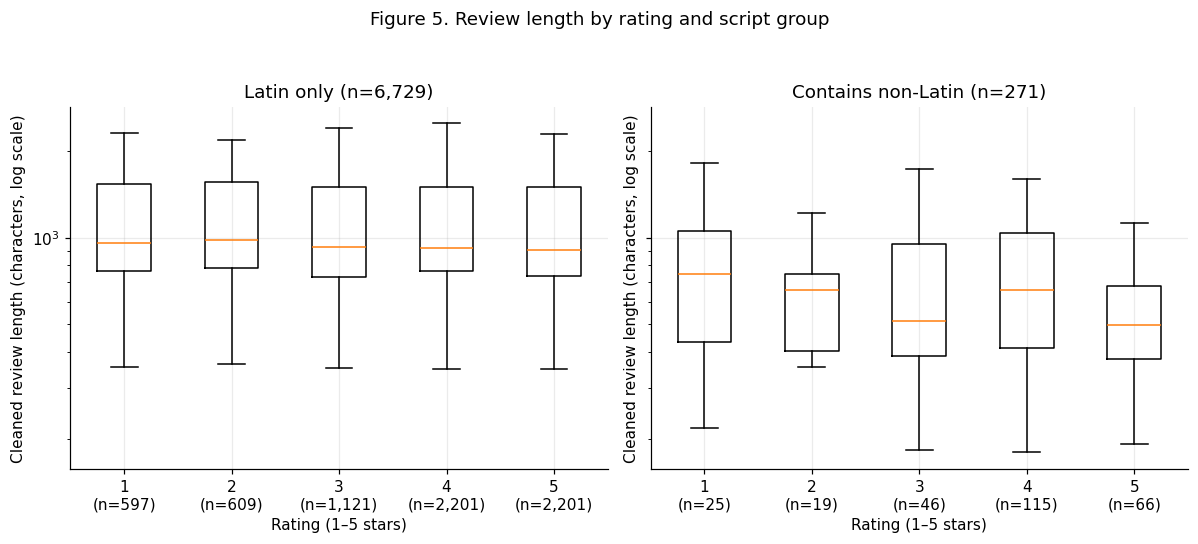

In [26]:
# --- Figure 5 (Shawn) ---
f5 = product_reviews[
    ["review_id", "rating", "review_length_chars", "contains_non_latin_script"]
].copy()
f5["rating"] = num(f5["rating"])
f5["review_length_chars"] = num(f5["review_length_chars"])

script_values = f5["contains_non_latin_script"].astype(str).str.lower()
assert script_values.isin(["true", "false"]).all()
assert f5[["rating", "review_length_chars"]].notna().all().all()
f5["script_group"] = script_values.map(
    {"false": "Latin only", "true": "Contains non-Latin"}
)

summary5 = (
    f5.groupby("script_group", observed=True)["review_length_chars"]
    .agg(n="size", median_chars="median")
    .reset_index()
)
print(summary5.to_string(index=False))

ratings = sorted(f5["rating"].astype(int).unique())
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=True)

for ax, group in zip(axes, ["Latin only", "Contains non-Latin"]):
    group_data = f5[f5["script_group"] == group]
    lengths = [
        group_data.loc[group_data["rating"] == rating, "review_length_chars"]
        for rating in ratings
    ]
    counts = [len(values) for values in lengths]
    ax.boxplot(lengths, showfliers=False)
    ax.set_xticks(range(1, len(ratings) + 1))
    ax.set_xticklabels(
        [f"{rating}\n(n={count:,})" for rating, count in zip(ratings, counts)]
    )
    ax.set_yscale("log")
    ax.set_title(f"{group} (n={len(group_data):,})")
    ax.set_xlabel("Rating (1–5 stars)")
    ax.set_ylabel("Cleaned review length (characters, log scale)")

fig.suptitle("Figure 5. Review length by rating and script group")
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()


### Figure 6: Delivery or operational performance

**Owner:** Echo

**Question:** Do late deliveries attract lower ratings?

**Observation unit and denominator:** One review. All 7,000 canonical reviews — item grain, not order grain, so this is not a count of orders.

**Tables and join keys:** `product_reviews` joined to `deliveries` on `order_id`, many reviews to one delivery. The cell prints the row count either side of the join.

**Result and limitation:** No. Late deliveries average 3.82 stars against 3.70 for on-time deliveries — a gap of +0.12 stars in the *opposite* direction to the expected effect, 2.5 standard errors on 707 late and 6,293 on-time reviews, and small beside a 1-5 scale. The defensible reading is that this data shows no rating penalty for lateness, not that lateness helps. Limitation: only reviewed items appear, so the sample describes reviewers rather than customers, and the late group is a tenth of the total. The review table's own `delivery_experience` field agrees with `on_time_in_full` on all 7,000 rows, so the review text is not an independent record of whether the delivery was late.


Before join: 7,000 reviews
After join: 7,000 rows, grain preserved
          mean  count
delivery             
On time   3.70   6293
Late      3.82    707


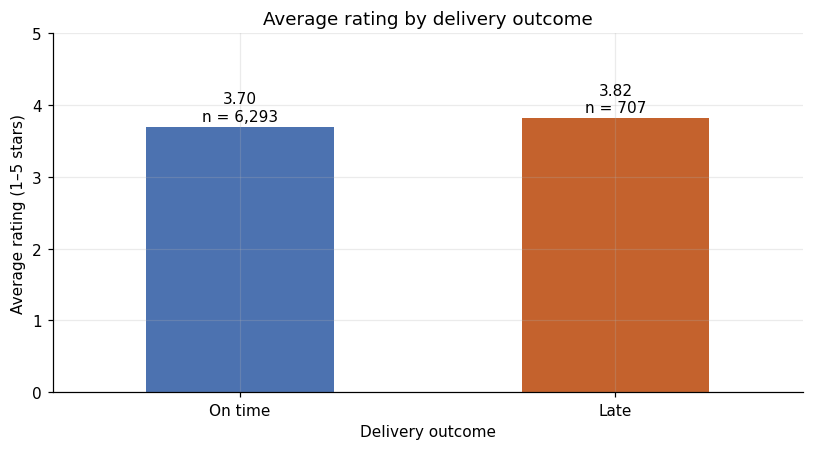

In [12]:
# --- Figure 6 (Echo) ---
print(f'Before join: {len(product_reviews):,} reviews')

rev = product_reviews[['order_id', 'rating']].merge(
    deliveries[['order_id', 'on_time_in_full']], on='order_id', how='left')
at_grain(rev, len(product_reviews), 'After join')
rev['rating'] = num(rev['rating'])
rev['delivery'] = rev['on_time_in_full'].astype(str).map(
    {'True': 'On time', 'False': 'Late'})

result = rev.groupby('delivery')['rating'].agg(['mean', 'count']).loc[['On time', 'Late']]
print(result.round(2))

ax = result['mean'].plot.bar(color=['#4C72B0', '#C4622D'], rot=0)
for i, row in enumerate(result.itertuples()):
    ax.text(i, row.mean + 0.08, f'{row.mean:.2f}\nn = {row.count:,}', ha='center')
ax.set(title='Average rating by delivery outcome', xlabel='Delivery outcome',
       ylabel='Average rating (1–5 stars)', ylim=(0, 5))
plt.tight_layout()
plt.show()

### Figure 7: Segmented relationship

**Owner:** Yandu

**Question:** Which customer segments spend the most, and is the difference explained by order count or by order size?

**Observation unit and denominator:** One customer. Denominator: all 500 customers.

**Tables and join keys:** `customers` joined to an aggregate of `orders` by `customer_id`. Aggregate first, then join — the other order multiplies customers by their order count. Verified with `at_grain(joined, len(customers), "customers + order summary")`; all 500 customers have at least one order, so the denominator is the full table.

**How to build it:** Aggregate `orders` to one row per customer, then join. Three horizontal-bar panels sharing one question — total spend, orders per customer, and average order value — so the left panel is the product of the other two and the reader can see which factor carries it. Splitting total spend this way is what makes this a segmented relationship rather than a second revenue chart.

**Interpretation and limitation:** Total spend does not separate the segments. The widest gap is Mainstream at AUD 31,360 against Small Business at AUD 28,897, which is 1.5 standard errors of the difference — indistinguishable on 110 to 139 customers per segment. The labels also do not rank as they read: Premium is third and Value second.

The components do differ, in opposite directions. Value customers order most often and spend least per order (10.4 orders, AUD 2,846); Small Business customers order least often and spend most per order (9.4 orders, AUD 3,062). Each gap is about 2.4 standard errors, and because they pull opposite ways the totals converge. Reading only the left panel would say these segments behave alike; they do not.

Two cautions. 2.4 standard errors is the largest of twelve comparisons across three measures, so the component gaps are suggestive rather than established. And `customer_segment` is a pre-existing label whose rule we do not have — `customers` also carries `prior_12m_orders` and `lifetime_value_before_period`, so if the segment was assigned from earlier behaviour, part of what this figure shows is the assignment rule rather than a finding about 2018.

customers + order summary: 500 rows, grain preserved


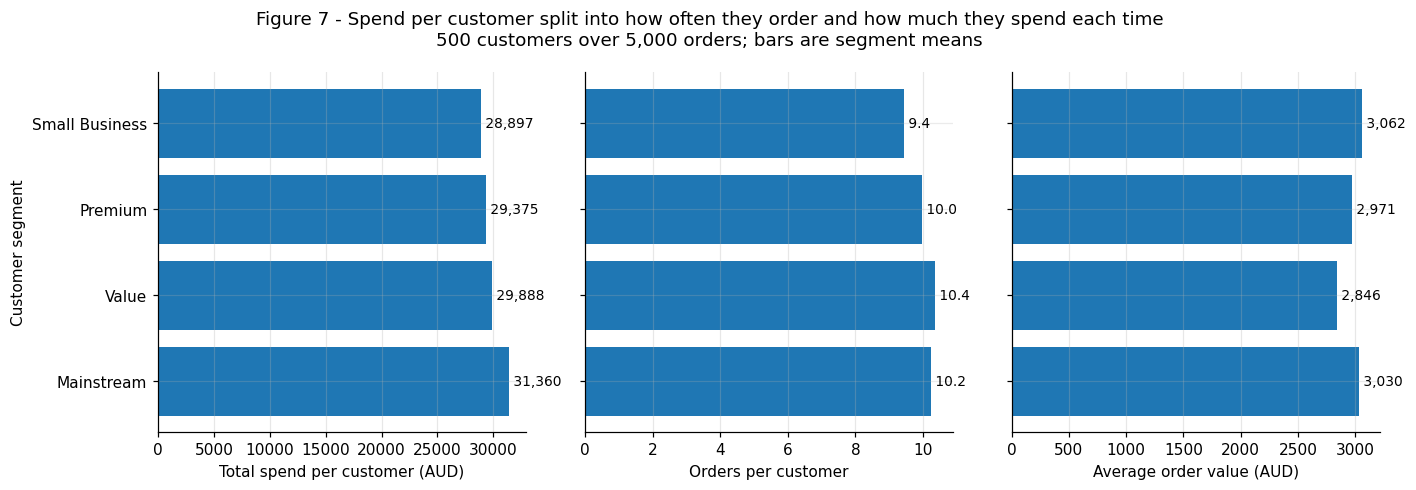

                  customers    spend  freq   size_
customer_segment                                  
Mainstream              110  31360.1  10.2  3030.1
Value                   139  29887.7  10.4  2845.9
Premium                 123  29374.6  10.0  2970.7
Small Business          128  28897.0   9.4  3062.2

spend per customer
                     mean      std  size      se
customer_segment                                
Mainstream        31360.1  13374.5   110  1275.2
Premium           29374.6   9947.7   123   897.0
Small Business    28897.0  12027.5   128  1063.1
Value             29887.7  11929.4   139  1011.8

orders
                  mean  std  size   se
customer_segment                      
Mainstream        10.2  3.5   110  0.3
Premium           10.0  2.8   123  0.3
Small Business     9.4  3.3   128  0.3
Value             10.4  3.1   139  0.3

avg order
                    mean    std  size    se
customer_segment                           
Mainstream        3030.1  685.4   110  

In [30]:
# --- Figure 7 (Yandu) ---
SEG = 'customer_segment'

# Aggregate first, then join - joining first multiplies each customer by their order count.
per_customer = (orders.assign(total=num(orders['order_total']))
                      .groupby('customer_id')
                      .agg(orders_placed=('order_id', 'size'), spend=('total', 'sum')))

joined = customers[['customer_id', SEG]].merge(per_customer, on='customer_id', how='left')
at_grain(joined, len(customers), 'customers + order summary')
joined['avg_order'] = joined['spend'] / joined['orders_placed']

seg = (joined.groupby(SEG)
             .agg(customers=('customer_id', 'size'),
                  spend=('spend', 'mean'),
                  freq=('orders_placed', 'mean'),
                  size_=('avg_order', 'mean'))
             .sort_values('spend', ascending=False))

fig, ax = plt.subplots(1, 3, figsize=(13, 4.5))
panels = [('spend', 'Total spend per customer (AUD)'),
          ('freq',  'Orders per customer'),
          ('size_', 'Average order value (AUD)')]

for a, (col, label) in zip(ax, panels):
    a.barh(seg.index, seg[col], color='tab:blue')
    a.set_xlabel(label)
    a.grid(axis='x', alpha=.3)
    for y, v in enumerate(seg[col]):
        a.text(v, y, f' {v:,.0f}' if v > 20 else f' {v:.1f}', va='center', fontsize=9)

ax[0].set_ylabel('Customer segment')
ax[1].set_yticklabels([])
ax[2].set_yticklabels([])
fig.suptitle('Figure 7 - Spend per customer split into how often they order and how much they spend each time\n'
             f'{len(joined):,} customers over {len(orders):,} orders; bars are segment means')
plt.tight_layout()
plt.show()

print(seg.round(1).to_string())
for col, label in [('spend', 'spend per customer'), ('orders_placed', 'orders'), ('avg_order', 'avg order')]:
    s = joined.groupby(SEG)[col].agg(['mean', 'std', 'size'])
    s['se'] = s['std'] / s['size'] ** .5
    print(f'\n{label}')
    print(s.round(1).to_string())

### Figure 8: Multivariate relationship

**Owner:** Shawn

**Question:** Does unit price relate to rating and to helpful votes, or are highly rated products simply the cheap ones?

**Observation unit and denominator:** One reviewed order item. Denominator: all 7,000 reviews.

**Tables and join keys:** `product_reviews` joins to `order_items` on `order_item_id`, then to `products` on `product_id`. `at_grain()` checks that both joins preserve the review grain.

**Method:** Divide reviewed items into five equal-frequency `unit_price` bins, print and label every bin size, and use two coordinated panels for mean rating and median helpful votes.

**Interpretation and limitation:** Across 7,000 reviewed items, mean rating moved from 3.879 in the lowest price quintile to 3.548 in the fourth and 3.684 in the highest, while median helpful votes stayed between 44.0 and 45.5, showing no clear monotonic price relationship. Only reviewed purchases are observed, and category mix, review age and exposure may confound the pattern, so it does not establish a causal price effect.

reviews + order items: 7,000 rows, grain preserved
reviews + order items + products: 7,000 rows, grain preserved
   n  min_price  max_price  mean_rating  median_helpful_votes
1402      14.38     323.81        3.879                  44.0
1401     325.21     629.04        3.799                  44.0
1398     634.07    1044.91        3.644                  44.0
1399    1047.53    1555.62        3.548                  45.0
1400    1570.55    4122.57        3.684                  45.5


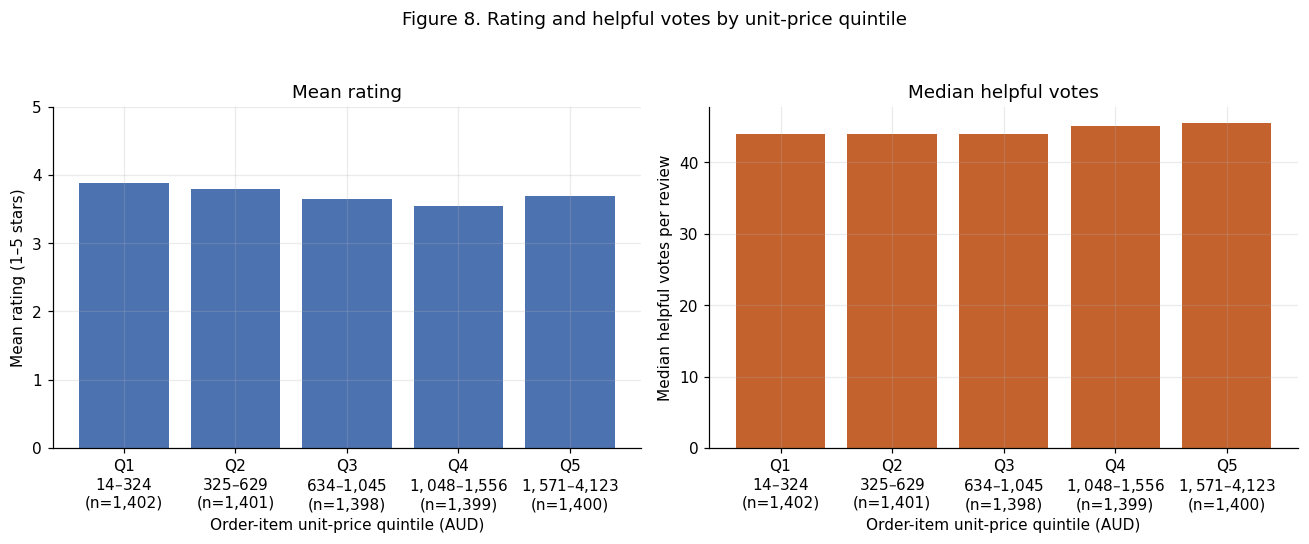

In [25]:
# --- Figure 8 (Shawn) ---
f8 = product_reviews[
    ["review_id", "order_item_id", "product_id", "rating", "helpful_votes"]
].rename(columns={"product_id": "review_product_id"}).copy()

item_prices = order_items[
    ["order_item_id", "product_id", "unit_price"]
].rename(columns={"unit_price": "item_unit_price"})
f8 = f8.merge(item_prices, on="order_item_id", how="left", validate="one_to_one")
at_grain(f8, len(product_reviews), "reviews + order items")
assert f8["review_product_id"].eq(f8["product_id"]).all()

catalogue_prices = products[["product_id", "unit_price"]].rename(
    columns={"unit_price": "catalogue_unit_price"}
)
f8 = f8.merge(catalogue_prices, on="product_id", how="left", validate="many_to_one")
at_grain(f8, len(product_reviews), "reviews + order items + products")

for column in ["item_unit_price", "catalogue_unit_price", "rating", "helpful_votes"]:
    f8[column] = num(f8[column])
assert f8[["item_unit_price", "catalogue_unit_price", "rating", "helpful_votes"]].notna().all().all()
assert f8["item_unit_price"].sub(f8["catalogue_unit_price"]).abs().le(0.01).all()

f8["price_quintile"] = pd.qcut(f8["item_unit_price"], q=5)
summary8 = (
    f8.groupby("price_quintile", observed=True)
    .agg(
        n=("review_id", "size"),
        min_price=("item_unit_price", "min"),
        max_price=("item_unit_price", "max"),
        mean_rating=("rating", "mean"),
        median_helpful_votes=("helpful_votes", "median"),
    )
    .reset_index(drop=True)
)
print(summary8.round(3).to_string(index=False))

labels = [
    f"Q{i + 1}\n${row.min_price:,.0f}–${row.max_price:,.0f}\n(n={int(row.n):,})"
    for i, row in enumerate(summary8.itertuples(index=False))
]
x = range(len(summary8))
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(x, summary8["mean_rating"], color="#4C72B0")
axes[0].set_ylim(0, 5)
axes[0].set_title("Mean rating")
axes[0].set_ylabel("Mean rating (1–5 stars)")

axes[1].bar(x, summary8["median_helpful_votes"], color="#C4622D")
axes[1].set_ylim(bottom=0)
axes[1].set_title("Median helpful votes")
axes[1].set_ylabel("Median helpful votes per review")

for ax in axes:
    ax.set_xticks(list(x))
    ax.set_xticklabels(labels)
    ax.set_xlabel("Order-item unit-price quintile (AUD)")

fig.suptitle("Figure 8. Rating and helpful votes by unit-price quintile")
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()


#### Coverage check

The specification requires the assessed set to cover all six published categories, use evidence
from at least four of the six output tables, and include at least two correct relational
analyses. This cell states which figure covers what, so the requirement is checked rather than
assumed.

In [15]:
# --- Coverage of the assessed set, checked rather than assumed ---
COVERAGE = {
    1: dict(categories={'univariate'},                 tables={'orders'},                            joins=0),
    2: dict(categories={'bivariate'},                  tables={'order_items', 'products'},           joins=1),
    3: dict(categories={'temporal'},                   tables={'orders'},                            joins=0),
    4: dict(categories={'multivariate', 'operational'},tables={'deliveries', 'orders'},              joins=1),
    5: dict(categories={'text'},                       tables={'product_reviews'},                   joins=0),
    6: dict(categories={'operational', 'bivariate'},   tables={'product_reviews', 'deliveries'},     joins=1),
    7: dict(categories={'multivariate'},               tables={'customers', 'orders'},               joins=1),
    8: dict(categories={'multivariate'},               tables={'product_reviews', 'order_items', 'products'}, joins=2),
}

REQUIRED = {'univariate', 'bivariate', 'multivariate', 'temporal', 'text', 'operational'}
seen_categories = set().union(*(f['categories'] for f in COVERAGE.values()))
seen_tables     = set().union(*(f['tables'] for f in COVERAGE.values()))
join_count      = sum(1 for f in COVERAGE.values() if f['joins'] > 0)

print(f'figures            {len(COVERAGE)}   (6 to 8 required)')
print(f'categories covered {len(seen_categories)}/6  missing: {sorted(REQUIRED - seen_categories) or "none"}')
print(f'tables used        {len(seen_tables)}/6  ({", ".join(sorted(seen_tables))})')
print(f'relational figures {join_count}     (at least 2 required)')

assert 6 <= len(COVERAGE) <= 8
assert REQUIRED <= seen_categories
assert len(seen_tables) >= 4
assert join_count >= 2
print('\ncoverage requirements met')

figures            8   (6 to 8 required)
categories covered 6/6  missing: none
tables used        6/6  (customers, deliveries, order_items, orders, product_reviews, products)
relational figures 5     (at least 2 required)

coverage requirements met


## 3. Ten evidence-based findings

Write exactly ten numbered findings. Keep each concise and decision-focused.
Each must identify the evidence, grain, magnitude/denominator, business meaning,
an alternative explanation or uncertainty, and a proportionate implication.
One figure may support more than one genuinely distinct finding.


*Each finding cites an assessed figure or a reported statistic, and carries all five parts:
what was observed and at what grain · magnitude, denominator or sample size · why it matters ·
an alternative explanation or uncertainty · a proportionate implication.*

1. **Finding 1** *(Echo, from Figure 2)* — At order-line grain across all 15,685 lines, category revenue rank and unit-sales rank are near-opposite: Laptop is 1st of ten on gross line revenue ($2.75m) and 9th on units (1,397); Accessory is 1st on units (3,051) and 10th on revenue ($0.56m). Range and promotion decisions taken on unit volume would therefore starve the categories that carry the revenue. The pattern may simply restate price level rather than any demand effect, and one year of one region cannot separate the two. Next step: repeat the ranking on margin once cost data exists.
2. **Finding 2** *(Echo, from Figure 6)* — Across all 7,000 reviews — item grain, joined to deliveries on `order_id` — late deliveries average 3.82 stars and on-time deliveries 3.70, a 0.12-star gap in the opposite direction to the expected one and 2.5 standard errors on 707 late reviews. Lateness is not a measurable driver of rating here, so service-recovery spend justified on review scores has no support in this data. Self-selection is the likelier explanation: only 7,000 of 15,685 items are reviewed and dissatisfied customers may not review at all. Next: measure the non-reviewing population before pricing any recovery programme.
3. **Finding 3** *(Jasmine, from Figure 3)* — Replace.
4. **Finding 4** *(Jasmine, from Figure 4)* — Replace.
5. **Finding 5** *(Yandu, from Figure 1)* — Replace.
6. **Finding 6** *(Yandu, from Figure 7)* — Replace.
7. **Finding 7** *(Shawn, from Figure 5)* — Replace.
8. **Finding 8** *(Shawn, from Figure 8)* — Replace.
9. **Finding 9** *(Yandu, from the validation register — no figure needed)* — The two sources
   agree completely where they overlap: across the keys carried by both files and every shared
   column, there are 0 field disagreements after normalisation, and 0 differences between the
   two copies of any within-source duplicate (`VAL-FLOW-09`, `VAL-FLOW-10`). *Add magnitude,
   the alternative explanation — that agreement may reflect a common upstream system rather
   than independent capture — and the implication for trusting either source alone.*
10. **Finding 10** *(Yandu, from the validation register — no figure needed)* —
    `deliveries.delivery_note_clean` is the same partition, row for row with zero disagreements
    across all 5,000 deliveries, as `delay_reason == 'none'`, `on_time_in_full`,
    `delay_days == 0` and `delivered_date <= promised_date`. It carries no information the
    outcome columns do not already carry. *Implication: it is a redundant feature that would
    leak the target into ML question 1.*

## 4. Five future machine-learning questions

Write exactly five numbered questions covering at least two problem types.
Model training is not required. Keep each response compact enough for the
ten-page report.


### MLQ-1 (Jasmine): Will this order be delivered later than promised?

| Element | Response |
|---|---|
| EDA evidence | *Cite the figure or finding and its quantified observation* |
| Business decision | *Replace* |
| Problem type and analysis unit | classification · one order at the moment it is placed |
| Target or unsupervised objective | `on_time_in_full`, or `delivered_date > promised_date` |
| Decision-time predictors | Order timestamp, sales channel, service level, carrier, promised days, shipping distance, delivery cost, cart size and value, customer history |
| Validation split | Temporal split — train on earlier months, test on later, because a random split lets the model see the future of the same period |
| Evaluation metric | Recall at a fixed alert budget, since the decision is which orders to intervene on |
| Leakage, fairness or deployment risk | **Target leakage is the whole problem here.** `delay_days`, `on_time_in_full`, `delay_reason` and `delivery_note_clean` are all recorded after delivery and all encode the answer — Finding 10 shows the note alone reproduces the outcome exactly. `delivered_date` is equally unavailable at decision time. |

### MLQ-2 (Echo): What will this basket be worth when the customer checks out?

| Element | Response |
|---|---|
| EDA evidence | Figure 2: order value is concentrated in high-price categories — Laptop earns $2.75m from 1,397 units while Accessory earns $0.56m from 3,051 — so what is in the cart, not how much is in it, carries the value |
| Business decision | How much fulfilment and delivery capacity to reserve against carts opened today, and when a free-delivery or bundle prompt is worth triggering mid-session |
| Problem type and analysis unit | regression · one order at the point the cart is opened |
| Target or unsupervised objective | `order_total` |
| Decision-time predictors | Customer history and segment, sales channel, time of day and month, items and categories currently in the cart |
| Validation split | Temporal split, with customers held out as a second check so the model is not simply memorising individual buyers |
| Evaluation metric | Mean absolute error in dollars, which is directly interpretable as the planning error |
| Leakage, fairness or deployment risk | `coupon_discount`, `tax_amount` and `order_price` are components of the target and are only known once the order is complete. Customer-level aggregates must be computed from orders strictly before the one being predicted. |


### MLQ-3 (Shawn): Which delivered items will attract a rating of 2 or below?

| Element | Response |
|---|---|
| EDA evidence | *Cite the figure or finding and its quantified observation* |
| Business decision | *Replace* |
| Problem type and analysis unit | classification · one delivered order item |
| Target or unsupervised objective | `rating <= 2` |
| Decision-time predictors | Product category and price, delivery lateness, carrier, service level, customer history, review language |
| Validation split | Temporal split on the order timestamp |
| Evaluation metric | Precision and recall on the low-rating class, reported with the base rate, because the class is the minority and accuracy would be uninformative |
| Leakage, fairness or deployment risk | **Selection bias:** only reviewed items appear at all — 7,000 reviews against 15,685 items — so the model learns the behaviour of customers who chose to review. `review_body_clean`, `review_length_chars` and `helpful_votes` are all recorded with the rating and are not available before it. |

### MLQ-4 (Yandu): What natural customer segments exist in purchasing behaviour?

| Element | Response |
|---|---|
| EDA evidence | *Cite the figure or finding and its quantified observation* |
| Business decision | *Replace* |
| Problem type and analysis unit | clustering · one customer |
| Target or unsupervised objective | No target. Objective: compact, well-separated groups on spend, frequency, recency, category mix and channel |
| Decision-time predictors | Order count, total and average order value, category shares, channel shares, signup recency, marketing consent |
| Validation split | No train/test split; stability is assessed by re-clustering bootstrap resamples and comparing assignments |
| Evaluation metric | Silhouette score for separation, plus a stability score across resamples |
| Leakage, fairness or deployment risk | With 500 customers the clusters may not be stable; features on different scales will dominate the distance unless standardised. **Fairness:** if a segment is used to price or to allocate service, check it is not a proxy for postcode. |

### MLQ-5 (Echo): What order volume should be planned for next month?

| Element | Response |
|---|---|
| EDA evidence | The temporal figure and the order table: all 5,000 canonical orders fall in 2018, giving a 12-point monthly series that runs between 384 and 443 orders a month with no visible seasonal swing |
| Business decision | How much warehouse and carrier capacity to book for the coming month, and how far ahead to place replenishment orders |
| Problem type and analysis unit | forecasting · one month, at the national level |
| Target or unsupervised objective | Monthly order count (and, as a second target, monthly revenue) |
| Decision-time predictors | Historic monthly volume, month of year, channel mix, promotion intensity |
| Validation split | Rolling-origin evaluation — fit to months 1..n, predict n+1, roll forward. A random split is invalid for a time series |
| Evaluation metric | Mean absolute percentage error against a seasonal-naive baseline, which is the only honest benchmark for a first forecast |
| Leakage, fairness or deployment risk | Twelve months is one cycle, so seasonality cannot be separated from trend and a flat series makes the naive baseline hard to beat — the honest output may be a range, not a point. Deliveries running into January belong to December orders and must not be counted as January demand. |


## 5. Limitations and conclusion

Summarise the most decision-relevant limitations, what the data cannot establish
and the next evidence needed. End with a concise conclusion rather than new
analysis.


*Owner: Jasmine. The most decision-relevant limitations, what this data cannot establish, and
the next evidence needed — then a short conclusion rather than new analysis.*

Starting points that are already evidenced rather than speculative:

- **One year, one region.** Seasonality cannot be separated from trend.
- **Three columns have no variance** — `order_status`, `delivery_status` and
  `verified_purchase` are single-valued across every row, so no analysis can use them.
- **Reviews are self-selected.** 7,000 reviews against 15,685 order items; every
  review-based finding describes reviewers, not customers.
- **Association is not causation** anywhere in this report — in particular between lateness
  and rating, where an unobserved product or seller effect could drive both.

## References

Use one consistent referencing style for external facts, code, data and ideas.
